# State Imaging Sanity Checks

Directly construct specific quantum states and verify the imaging pipeline
handles them correctly.

| Case | State | Expected |
|------|-------|----------|
| 1 | \|g,0⟩ | Single blob in **ground** channel only |
| 2 | \|e,0⟩ | Single blob in **excited** channel only |
| 3 | ½\|g,0⟩ + ½\|g,1⟩ same position | **Ground** channel: constructive interference → 2× peak |
| 4 | ½\|g,0⟩ + ½\|e,0⟩ same position | Ground AND excited each show ½-bright blob independently |
| 5 | ½\|g,0⟩ + ½\|g,1⟩ 5 µm apart | **Ground**: single merged blob (sep < blur σ = 10 µm) |
| 6 | ½\|g,0⟩ + ½\|g,1⟩ 20 µm apart | **Ground**: two partially resolved blobs (sep = 2× blur σ) |

Key parameter: `SINGLE_ATOM_WAVEPACKET_SIGMA_M = 10 µm` sets the blur
scale that determines when nearby branches interfere vs resolve.

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

import lmt_sim.version_info as vs
from lmt_sim.lmt_simulation import AtomState, RECOIL_VELOCITY
from lmt_sim.imaging import (
    collect_branches, render, pixel_grid, SINGLE_ATOM_WAVEPACKET_SIGMA_M
)

print(f"Wavepacket blur σ = {SINGLE_ATOM_WAVEPACKET_SIGMA_M*1e6:.0f} µm")
print(f"Recoil velocity   = {RECOIL_VELOCITY*1e3:.4f} mm/s")

Wavepacket blur σ = 10 µm
Recoil velocity   = 6.5710 mm/s


In [2]:
def make_state(branches):
    """Build an AtomState from a list of branch specs.

    Each branch: (m, x, y, z, amp, is_ground)
    vz is set consistently as m * RECOIL_VELOCITY (v0=0 reference).
    """
    return AtomState(
        m_values          = np.array([b[0] for b in branches], dtype=int),
        positions         = np.array([[b[1], b[2], b[3]] for b in branches], dtype=float),
        velocities        = np.array([[0.0, 0.0, b[0]*RECOIL_VELOCITY] for b in branches],
                                     dtype=float),
        amplitudes        = np.array([b[4] for b in branches], dtype=complex),
        internal_is_ground= np.array([b[5] for b in branches], dtype=bool),
    )

a = 1.0 / np.sqrt(2)   # equal-superposition amplitude

CASES = [
    # (title, state)
    ("|g,0⟩ only",
     make_state([(0, 0,0, 0,      1.0, True )])),

    ("|e,0⟩ only",
     make_state([(0, 0,0, 0,      1.0, False)])),

    ("|g,0⟩+|g,1⟩\nsame pos",
     make_state([(0, 0,0, 0,        a, True ),
                 (1, 0,0, 0,        a, True )])),

    ("|g,0⟩+|e,0⟩\nsame pos",
     make_state([(0, 0,0, 0,        a, True ),
                 (0, 0,0, 0,        a, False)])),

    ("|g,0⟩+|g,1⟩\n5 µm sep",
     make_state([(0, 0,0, -2.5e-6,  a, True ),
                 (1, 0,0, +2.5e-6,  a, True )])),

    ("|g,0⟩+|g,1⟩\n20 µm sep",
     make_state([(0, 0,0, -10e-6,   a, True ),
                 (1, 0,0, +10e-6,   a, True )])),
]

print(f"{len(CASES)} cases defined")
for title, _ in CASES:
    print(f"  {title.replace(chr(10), ' / ')}")

6 cases defined
  |g,0⟩ only
  |e,0⟩ only
  |g,0⟩+|g,1⟩ / same pos
  |g,0⟩+|e,0⟩ / same pos
  |g,0⟩+|g,1⟩ / 5 µm sep
  |g,0⟩+|g,1⟩ / 20 µm sep


Ground vmax = 2.922e-05   Excited vmax = 1.461e-05


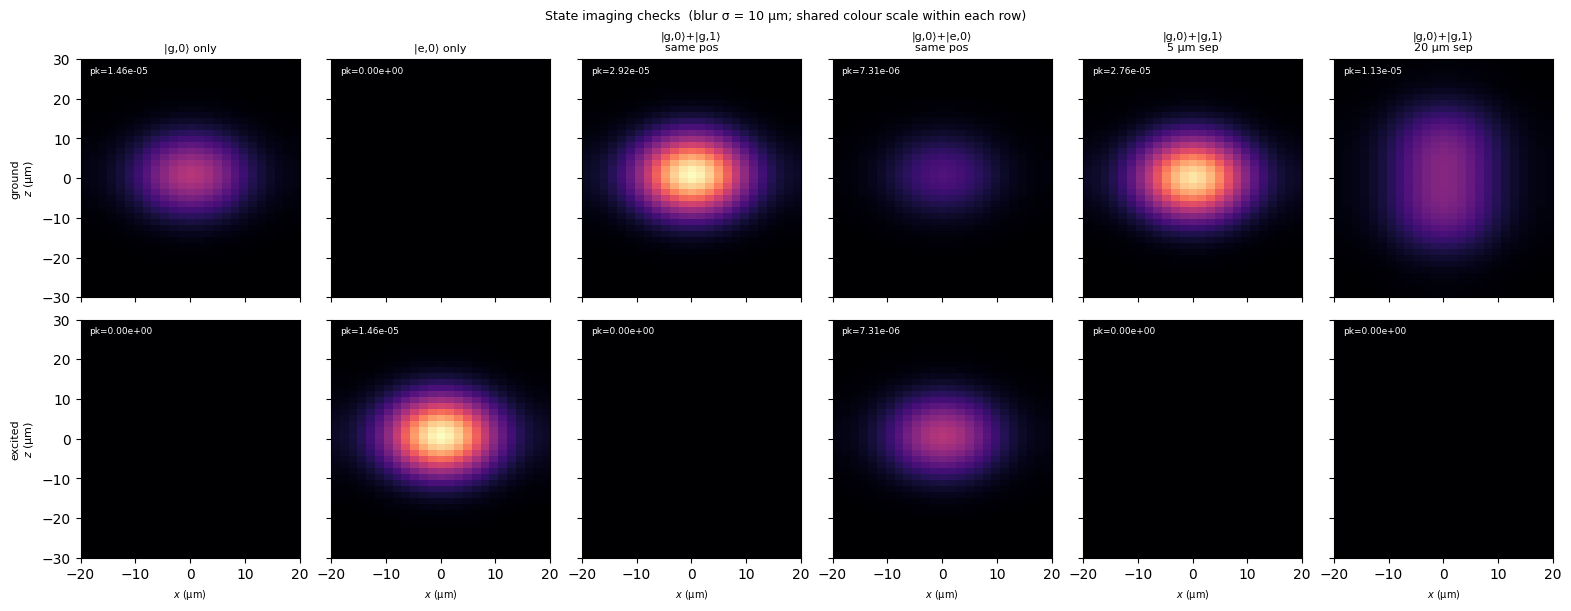

In [3]:
# Collect branches and build a shared pixel grid from all positions
branch_pairs = [collect_branches(state) for _, state in CASES]
all_branches = [b for g, e in branch_pairs for b in (g, e) if len(b)]

# x_pad_min=20µm ensures single-point cases show enough room around the blob;
# z_pad_min=20µm similarly, and also ensures the 20µm-separated case is framed well.
x_edges, z_edges = pixel_grid(all_branches, n_x=25, n_z=40,
                               x_pad_min=20e-6, z_pad_min=20e-6)

imgs_g = [render(g, x_edges, z_edges) for g, e in branch_pairs]
imgs_e = [render(e, x_edges, z_edges) for g, e in branch_pairs]

# Separate colour-scale ceilings for ground and excited rows
vmax_g = max(img.max() for img in imgs_g) or 1.0
vmax_e = max(img.max() for img in imgs_e) or 1.0
print(f"Ground vmax = {vmax_g:.3e}   Excited vmax = {vmax_e:.3e}")

extent = [1e6*x_edges[0], 1e6*x_edges[-1],
          1e6*z_edges[0], 1e6*z_edges[-1]]
n_cases = len(CASES)

fig, axes = plt.subplots(2, n_cases,
                          figsize=(2.6 * n_cases, 6.0),
                          sharex=True, sharey=True,
                          constrained_layout=True)

for col, (title, _) in enumerate(CASES):
    for row, (img, vmax, channel) in enumerate(
        zip([imgs_g[col], imgs_e[col]], [vmax_g, vmax_e], ["ground", "excited"])
    ):
        ax = axes[row, col]
        ax.imshow(img, origin="lower", aspect="auto", extent=extent,
                  cmap="magma", vmin=0, vmax=vmax)
        if row == 0:
            ax.set_title(title, fontsize=8)
        if col == 0:
            ax.set_ylabel(f"{channel}\n" + r"$z$ (µm)", fontsize=8)
        if row == 1:
            ax.set_xlabel(r"$x$ (µm)", fontsize=7)
        ax.text(0.04, 0.97, f"pk={img.max():.2e}",
                transform=ax.transAxes, fontsize=6.5, color="white", va="top")

fig.suptitle(
    f"State imaging checks  (blur σ = {SINGLE_ATOM_WAVEPACKET_SIGMA_M*1e6:.0f} µm; "
    "shared colour scale within each row)",
    fontsize=9,
)
vs.tag_plot(small=True)
plt.show()

## Observations

**Cases 1 & 2** — channel separation works: a pure ground state appears only in
the ground row, a pure excited state only in the excited row.

**Case 3 vs Cases 1/2** — constructive interference between co-located g,0 and
g,1 branches produces a ground-channel peak ≈ 2× that of a single-branch state
at the same total probability (each branch carries amplitude 1/√2 so the
coherent field sums to √2, and √2² = 2).

**Case 4** — ground and excited channels are independent: each shows a blob at
≈ ½ of the single-branch peak, and nothing appears in the other channel.

**Case 5 (5 µm sep < blur σ = 10 µm)** — the two branches overlap almost
completely within the blur kernel so they interfere like co-located branches;
expect a single blob close in brightness to Case 3.

**Case 6 (20 µm sep = 2× blur σ)** — the blobs are partially resolved; expect
two distinct peaks with reduced intensity at each (the branches contribute
less coherent field at each other's centres).